In [ ]:
import os
!git clone https://github.com/ia-project-parasite/IA-PROJECT-PARASITE-REPO.git
os.chdir('IA-PROJECT-PARASITE-REPO')

Cloning into 'IA-PROJECT-PARASITE-REPO'...
remote: Enumerating objects: 431, done.
remote: Counting objects: 100% (86/86), done.
remote: Compressing objects: 100% (70/70), done.
remote: Total 431 (delta 20), reused 77 (delta 16), pack-reused 345 (from 1)
Receiving objects: 100% (431/431), 730.61 MiB | 48.35 MiB/s, done.
Resolving deltas: 100% (139/139), done.
Updating files: 100% (206/206), done.


In [ ]:
!pip install -q torch torchvision
!pip install -q git+https://github.com/facebookresearch/segment-anything.git
!pip install -q opencv-python scikit-image pandas numpy matplotlib tqdm scikit-learn
!pip install -q loralib

  Preparing metadata (setup.py) ... done


In [ ]:
import os
import cv2
import numpy as np
import json
from pathlib import Path
from tqdm import tqdm
from PIL import Image
from scipy.ndimage import label as ndimage_label
from skimage.morphology import remove_small_holes, remove_small_objects
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from collections import defaultdict
import random
import shutil
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
import torch.nn as nn
from segment_anything import sam_model_registry
import loralib as lora  # LoRA library

## Dataset Preprocessing Functions

In [ ]:
def apply_clahe_and_brightness(bgr):
    """Apply CLAHE + brightness boost."""
    img_lab = cv2.cvtColor(bgr, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(img_lab)
    clahe = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8, 8))
    l2 = clahe.apply(l)
    img_lab = cv2.merge((l2, a, b))
    bgr_corr = cv2.cvtColor(img_lab, cv2.COLOR_LAB2BGR)

    hsv = cv2.cvtColor(bgr_corr, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(hsv)
    v = cv2.add(v, 15)
    hsv = cv2.merge([h, s, v])
    bgr_corr = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)
    return bgr_corr


def specimen_mask(bgr, use_hull=False):
    """Generate binary mask for specimen."""
    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
    H, S, V = cv2.split(hsv)

    ret, _ = cv2.threshold(V, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    v_thr, s_thr = int(max(ret * 0.7, 25)), 15
    m = ((V >= v_thr) & (S >= s_thr)).astype(np.uint8)

    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    m = cv2.morphologyEx(m, cv2.MORPH_OPEN, k)
    m = cv2.morphologyEx(m, cv2.MORPH_CLOSE, k)
    m = remove_small_objects(m.astype(bool), min_size=3000)
    m = remove_small_holes(m, area_threshold=50000).astype(np.uint8)

    n, lab = cv2.connectedComponents(m)
    if n <= 1:
        return np.zeros(m.shape, bool)
    cnts = np.bincount(lab.ravel())[1:]
    keep = 1 + np.argmax(cnts)
    m = (lab == keep).astype(np.uint8)

    if use_hull:
        contours, _ = cv2.findContours(m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if contours:
            hull = cv2.convexHull(np.vstack(contours))
            m_hull = np.zeros_like(m)
            cv2.drawContours(m_hull, [hull], -1, 1, -1)
            m = m_hull

    return m.astype(bool)


def roi_from_mask(img, mask, pad=10):
    """Extract ROI bounding box."""
    ys, xs = np.where(mask)
    if len(ys) == 0 or len(xs) == 0:
        return None, None, None
    y0, y1 = max(0, ys.min() - pad), min(img.shape[0], ys.max() + pad)
    x0, x1 = max(0, xs.min() - pad), min(img.shape[1], xs.max() + pad)
    return (y0, y1, x0, x1), img[y0:y1, x0:x1], mask[y0:y1, x0:x1]


def get_white_points_from_label(label_img):
    """Extract white pixel coordinates from label image."""
    if len(label_img.shape) == 3:
        gray = cv2.cvtColor(label_img, cv2.COLOR_BGR2GRAY)
    else:
        gray = label_img

    _, thresh = cv2.threshold(gray, 200, 255, cv2.THRESH_BINARY)
    ys, xs = np.where(thresh > 0)

    if len(xs) == 0:
        return []

    points = [(int(x), int(y)) for x, y in zip(xs, ys)]
    return points


def extract_centroids_from_points(points, img_shape):
    """Convert dense point cloud to centroids."""
    if len(points) == 0:
        return []

    binary_mask = np.zeros(img_shape[:2], dtype=np.uint8)
    for x, y in points:
        if 0 <= y < img_shape[0] and 0 <= x < img_shape[1]:
            binary_mask[y, x] = 255

    labeled_mask, num_parasites = ndimage_label(binary_mask)

    centroids = []
    for region_id in range(1, num_parasites + 1):
        ys, xs = np.where(labeled_mask == region_id)
        if len(ys) > 0:
            centroid_x = int(xs.mean())
            centroid_y = int(ys.mean())
            centroids.append((centroid_x, centroid_y))

    return centroids

## Tiling Functions

In [ ]:
def split_images_fixed_grid(original_img, label_img, mask_img, points, tile_size=1024, roi_bbox=None):
    """
    Split images into FIXED tile_size grid (NO OVERLAP).

    Returns list of tile dictionaries with metadata.
    """
    height, width = original_img.shape[:2]
    tiles = []
    tile_count = 0

    for y in range(0, height, tile_size):
        for x in range(0, width, tile_size):
            box = (x, y, min(x + tile_size, width), min(y + tile_size, height))
            x1, y1, x2, y2 = box

            # Crop tiles
            tile_original = original_img[y1:y2, x1:x2]
            tile_label = label_img[y1:y2, x1:x2]
            tile_mask = mask_img[y1:y2, x1:x2] if mask_img is not None else None

            # Pad to tile_size if needed (for edge tiles)
            actual_h, actual_w = tile_original.shape[:2]
            if actual_h < tile_size or actual_w < tile_size:
                padded_original = np.zeros((tile_size, tile_size, 3), dtype=np.uint8)
                padded_original[:actual_h, :actual_w] = tile_original

                if len(tile_label.shape) == 3:
                    padded_label = np.zeros((tile_size, tile_size, 3), dtype=np.uint8)
                else:
                    padded_label = np.zeros((tile_size, tile_size), dtype=np.uint8)
                padded_label[:actual_h, :actual_w] = tile_label

                if tile_mask is not None:
                    padded_mask = np.zeros((tile_size, tile_size), dtype=np.uint8)
                    padded_mask[:actual_h, :actual_w] = tile_mask
                else:
                    padded_mask = None

                tile_original = padded_original
                tile_label = padded_label
                tile_mask = padded_mask

            # Find points in this tile
            tile_points = []
            for px, py in points:
                if x1 <= px < x2 and y1 <= py < y2:
                    tile_points.append((px - x1, py - y1))

            # Only save tiles with parasites
            if len(tile_points) > 0:
                tiles.append({
                    'tile_original': tile_original,
                    'tile_label': tile_label,
                    'tile_mask': tile_mask,
                    'points_local': tile_points,
                    'tile_id': f"tile_{tile_count:04d}",
                    'global_bbox': (x1, y1, x2, y2),
                    'num_parasites': len(tile_points)
                })
                tile_count += 1

    return tiles


def process_image_complete(image_path, label_path, mask_path, image_id,
                          tile_size=1024, apply_clahe=True, extract_roi=True):
    """
    Complete preprocessing pipeline:
    1. Load images
    2. Apply CLAHE
    3. Extract ROI
    4. Convert labels to centroids
    5. Split into tiles
    """
    # Load images
    img = cv2.imread(image_path)
    label = cv2.imread(label_path)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE) if mask_path and os.path.exists(mask_path) else None

    if img is None or label is None:
        print(f"Warning: Could not read {image_id}")
        return []

    original_shape = img.shape

    # Apply preprocessing
    if apply_clahe:
        img = apply_clahe_and_brightness(img)

    # Extract ROI
    roi_bbox = None
    if extract_roi:
        specimen_m = specimen_mask(img, use_hull=False)
        bbox, img_roi, mask_roi = roi_from_mask(img, specimen_m, pad=10)

        if bbox is None:
            img_roi = img
            label_roi = label
            mask_roi_img = mask
        else:
            y0, y1, x0, x1 = bbox
            roi_bbox = bbox
            img_roi = img_roi.copy()
            img_roi[~mask_roi] = 0
            label_roi = label[y0:y1, x0:x1]
            mask_roi_img = mask[y0:y1, x0:x1] if mask is not None else None
    else:
        img_roi = img
        label_roi = label
        mask_roi_img = mask

    # Extract centroids
    points = get_white_points_from_label(label_roi)
    if len(points) == 0:
        return []

    centroids = extract_centroids_from_points(points, label_roi.shape)
    print(f"  [{image_id}] {len(points)} pixels → {len(centroids)} centroids")

    if len(centroids) == 0:
        return []

    # Split into tiles
    tiles = split_images_fixed_grid(img_roi, label_roi, mask_roi_img, centroids,
                                    tile_size=tile_size, roi_bbox=roi_bbox)

    # Add metadata
    for tile in tiles:
        tile['image_id'] = f"{image_id}_{tile['tile_id']}"
        tile['base_image_id'] = image_id
        tile['original_shape'] = original_shape
        tile['roi_bbox'] = roi_bbox

    return tiles

## Create Dataset

In [ ]:
museum_labels_dir = "Museum labels"
output_dir = "Combined_Dataset"
TILE_SIZE = 1024

os.makedirs(output_dir, exist_ok=True)

# Find all folders
folders = [f for f in os.listdir(museum_labels_dir)
           if os.path.isdir(os.path.join(museum_labels_dir, f))]

all_tiles = []
tiles_per_image = {}


for folder in tqdm(folders, desc="Processing images"):
    folder_path = os.path.join(museum_labels_dir, folder)

    # Look for files
    raw_img_path = os.path.join(folder_path, f"{folder}.JPG")
    label_mask_path = os.path.join(folder_path, f"{folder}_labels.png")
    mask_path = os.path.join(folder_path, f"{folder}_mask.png")

    # Check alternative extension
    if not os.path.exists(label_mask_path):
        label_mask_path = os.path.join(folder_path, f"{folder}_labels.JPG")

    if not os.path.exists(raw_img_path) or not os.path.exists(label_mask_path):
        continue

    # Process image
    tiles = process_image_complete(
        raw_img_path,
        label_mask_path,
        mask_path if os.path.exists(mask_path) else None,
        folder,
        tile_size=TILE_SIZE,
        apply_clahe=True,
        extract_roi=True
    )

    if len(tiles) == 0:
        continue

    # Create folder structure
    image_output_dir = os.path.join(output_dir, folder)
    tiles_dir = os.path.join(image_output_dir, "tiles")
    labels_dir = os.path.join(image_output_dir, "labels")
    masks_dir = os.path.join(image_output_dir, "masks")
    annotations_dir = os.path.join(image_output_dir, "annotations")

    os.makedirs(tiles_dir, exist_ok=True)
    os.makedirs(labels_dir, exist_ok=True)
    os.makedirs(masks_dir, exist_ok=True)
    os.makedirs(annotations_dir, exist_ok=True)

    # Save tiles
    for tile in tiles:
        tile_id = tile['tile_id']

        # Save images
        cv2.imwrite(os.path.join(tiles_dir, f"{tile_id}.png"), tile['tile_original'])
        cv2.imwrite(os.path.join(labels_dir, f"{tile_id}.png"), tile['tile_label'])

        if tile['tile_mask'] is not None:
            cv2.imwrite(os.path.join(masks_dir, f"{tile_id}.png"), tile['tile_mask'])

        # Save annotations
        x1_global, y1_global, x2_global, y2_global = tile['global_bbox']

        annotation_data = {
            'tile_id': tile['image_id'],
            'base_image_id': tile['base_image_id'],
            'num_parasites': tile['num_parasites'],
            'centroids_local': [[int(x), int(y)] for x, y in tile['points_local']],
            'centroids_global': [[int(x + x1_global), int(y + y1_global)]
                                for x, y in tile['points_local']],
            'bboxes_local': [[max(0, int(x - 20)), max(0, int(y - 20)),
                             min(TILE_SIZE, int(x + 20)), min(TILE_SIZE, int(y + 20))]
                            for x, y in tile['points_local']],
            'box_size': 40,
            'tile_bbox': [int(x1_global), int(y1_global), int(x2_global), int(y2_global)],
            'original_shape': [int(d) for d in tile['original_shape']],
            'roi_bbox': [int(d) for d in tile['roi_bbox']] if tile['roi_bbox'] else None
        }

        with open(os.path.join(annotations_dir, f"{tile_id}.json"), 'w') as f:
            json.dump(annotation_data, f, indent=2)

    all_tiles.extend(tiles)
    tiles_per_image[folder] = len(tiles)


print(f"Total images: {len(tiles_per_image)}")
print(f"Total tiles: {len(all_tiles)}")
print(f"Total parasites: {sum(t['num_parasites'] for t in all_tiles)}")
print(f"\nTiles per image: {tiles_per_image}")

Processing images:   0%|          | 0/44 [00:00<?, ?it/s]

  [B2025-00231b] 2965 pixels → 83 centroids


Processing images:   5%|▍         | 2/44 [00:16<05:21,  7.67s/it]

  [B2025-00139a] 12 pixels → 12 centroids


Processing images:   7%|▋         | 3/44 [00:21<04:13,  6.18s/it]

...

  [B2025-00130e] 170 pixels → 170 centroids


Processing images:  98%|█████████▊| 43/44 [08:43<00:09,  9.65s/it]

  [B2025-00085e] 568 pixels → 157 centroids


Processing images: 100%|██████████| 44/44 [08:57<00:00, 12.20s/it]

Total images: 44
Total tiles: 312
Total parasites: 9703

Tiles per image: {'B2025-00231b': 6, 'B2025-00139a': 4, 'B2025-00084n': 3, 'B2025-00158a': 10, 'B2025-00234a': 4, 'B2025-00139b': 8, 'B2025-00153b': 7, 'B2025-00176a': 6, 'B2025-00146a': 9, 'B2025-00143b': 7, 'B2025-00150a': 8, 'B2025-00150c': 10, 'B2025-00173b': 5, 'B2025-00234b': 3, 'B2025-00149d': 8, 'B2025-00172b': 7, 'B2025-00141c': 7, 'B2025-00153a': 10, 'B2025-00173a': 8, 'B2025-00171a': 6, 'B2025-00138b': 5, 'B2025-00146c': 8, 'B2025-00182c': 6, 'B2025-00136b': 7, 'B2025-00130c': 9, 'B2025-00206b': 6, 'B2025-00141a': 6, 'B2025-00155e': 8, 'B2025-00142a': 1, 'B2025-00140b': 7, 'B2025-00137d': 8, 'B2025-00137b': 10, 'B2025-00156a': 7, 'B2025-00158b': 6, 'B2025-00144b': 9, 'B2025-00086a': 8, 'B2025-00139a-1': 2, 'B2025-00130b': 8, 'B2025-00176b': 6, 'B2025-00085k': 10, 'B2025-00085.2': 9, 'B2025-00172a': 9, 'B2025-00130e': 7, 'B2025-00085e': 14}


## Loading from Google Collab

In [ ]:
import os
from google.colab import drive

drive.mount('/content/drive')

output_dir = '/content/drive/MyDrive/Parasite_Dataset_Processed'

Mounted at /content/drive


## Split Dataset (Train/Val/Test)

In [ ]:
splits = {
    'train': [
        'B2025-00085e', 'B2025-00085k',
        'B2025-00150a', 'B2025-00150c',
        'B2025-00130b', 'B2025-00130c',
        'B2025-00158a', 'B2025-00158b',
        'B2025-00172a', 'B2025-00172b',
        'B2025-00173a', 'B2025-00173b',
        'B2025-00141a', 'B2025-00141c',
        'B2025-00176a', 'B2025-00176b',
        'B2025-00153a',
        'B2025-00146c', 'B2025-00137b',
        'B2025-00149d', 'B2025-00146a',
        'B2025-00144b', 'B2025-00156a',
        'B2025-00155e', 'B2025-00139b',
        'B2025-00137d',
        'B2025-00086a', 'B2025-00140b'
    ],

    'val': [
        'B2025-00234a', 'B2025-00084n',
        'B2025-00139a', 'B2025-00139a-1',
        'B2025-00138b', 'B2025-00171a',
        'B2025-00182c'
    ],

    'test': [
        'B2025-00231b', 'B2025-00143b',
        'B2025-00206b', 'B2025-00136b',
        'B2025-00085.2', 'B2025-00142a'
    ]
}

print(f"Train: {len(splits['train'])} images")
print(f"Val:   {len(splits['val'])} images")
print(f"Test:  {len(splits['test'])} images")
print(f"\nTrain images: {splits['train']}")
print(f"Val images:   {splits['val']}")
print(f"Test images:  {splits['test']}")

Train: 28 images
Val:   7 images
Test:  6 images

Train images: ['B2025-00085e', 'B2025-00085k', 'B2025-00150a', 'B2025-00150c', 'B2025-00130b', 'B2025-00130c', 'B2025-00158a', 'B2025-00158b', 'B2025-00172a', 'B2025-00172b', 'B2025-00173a', 'B2025-00173b', 'B2025-00141a', 'B2025-00141c', 'B2025-00176a', 'B2025-00176b', 'B2025-00153a', 'B2025-00146c', 'B2025-00137b', 'B2025-00149d', 'B2025-00146a', 'B2025-00144b', 'B2025-00156a', 'B2025-00155e', 'B2025-00139b', 'B2025-00137d', 'B2025-00086a', 'B2025-00140b']
Val images:   ['B2025-00234a', 'B2025-00084n', 'B2025-00139a', 'B2025-00139a-1', 'B2025-00138b', 'B2025-00171a', 'B2025-00182c']
Test images:  ['B2025-00231b', 'B2025-00143b', 'B2025-00206b', 'B2025-00136b', 'B2025-00085.2', 'B2025-00142a']


## Dataset Class for PyTorch

In [ ]:
class SAMDatasetNoPrompt_Fixed(Dataset):
    """
    FIXED Dataset for SAM fine-tuning with proper ImageNet normalization

    Key fix: Added ImageNet normalization that SAM was trained with
    """

    def __init__(self, image_ids, output_dir, augment=False):
        """
        Args:
            image_ids: List of image IDs to load
            output_dir: Base directory containing processed tiles
            augment: Whether to apply augmentation (only for training)
        """
        self.samples = []
        self.augment = augment

        # SAM's ImageNet normalization (CRITICAL FIX!)
        self.pixel_mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        self.pixel_std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

        # Load all samples
        for img_id in image_ids:
            tiles_dir = os.path.join(output_dir, img_id, "tiles")
            masks_dir = os.path.join(output_dir, img_id, "masks")
            annotations_dir = os.path.join(output_dir, img_id, "annotations")

            if not os.path.exists(tiles_dir):
                continue

            tile_files = [f for f in os.listdir(tiles_dir) if f.endswith('.png')]

            for tile_file in tile_files:
                tile_id = tile_file.replace('.png', '')
                tile_path = os.path.join(tiles_dir, tile_file)
                mask_path = os.path.join(masks_dir, f"{tile_id}.png")
                anno_path = os.path.join(annotations_dir, f"{tile_id}.json")

                if os.path.exists(mask_path) and os.path.exists(anno_path):
                    with open(anno_path, 'r') as f:
                        anno = json.load(f)

                    self.samples.append({
                        'tile_path': tile_path,
                        'mask_path': mask_path,
                        'tile_id': tile_id,
                        'base_image_id': img_id,
                        'num_parasites': anno['num_parasites']
                    })

        print(f"Loaded {len(self.samples)} samples (augment={augment}, normalized=ImageNet)")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]

        # Load image and mask
        image = cv2.imread(sample['tile_path'])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(sample['mask_path'], cv2.IMREAD_GRAYSCALE)
        binary_mask = (mask > 127).astype(np.float32)

        # Apply augmentation with .copy() to avoid negative strides
        if self.augment:
            if random.random() > 0.5:
                image = cv2.flip(image, 1).copy()
                binary_mask = cv2.flip(binary_mask, 1).copy()
            if random.random() > 0.5:
                image = cv2.flip(image, 0).copy()
                binary_mask = cv2.flip(binary_mask, 0).copy()
            if random.random() > 0.5:
                k = random.choice([1, 2, 3])
                image = np.rot90(image, k).copy()
                binary_mask = np.rot90(binary_mask, k).copy()

        # Convert to tensor and scale to [0, 1]
        image_tensor = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0

        # ⭐ CRITICAL FIX: Apply SAM's ImageNet normalization
        image_tensor = (image_tensor - self.pixel_mean) / self.pixel_std

        mask_tensor = torch.from_numpy(binary_mask).unsqueeze(0).float()

        return {
            'image': image_tensor,
            'mask': mask_tensor,
            'tile_id': sample['tile_id'],
            'num_parasites': sample['num_parasites']
        }

## SAM Fine-Tuner with LoRA



In [ ]:
class SAMFineTuner_LoRA:
    def __init__(self, sam_model, device, learning_rate=1e-4, lora_rank=8,
                 optimizer_type='adam', weight_decay=1e-4,
                 bce_weight=1.0, dice_weight=1.0, grad_clip=None):
        """
        SAM Fine-tuner with LoRA
        Args:
            sam_model: SAM model
            device: cuda or cpu
            learning_rate: Learning rate (default 1e-4)
            lora_rank: LoRA rank (default 8)
            optimizer_type: 'adam', 'adamw', or 'sgd' (default 'adam')
            weight_decay: Weight decay for optimizer (default 1e-4)
            bce_weight: Weight for BCE loss (default 1.0)
            dice_weight: Weight for Dice loss (default 1.0)
            grad_clip: Gradient clipping max norm (default None)
        """
        self.sam = sam_model
        self.device = device
        self.lora_rank = lora_rank
        self.grad_clip = grad_clip
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight

        # Apply LoRA to image encoder
        self._apply_lora_to_image_encoder()

        # Freeze base image encoder parameters (LoRA params will be trainable)
        for name, param in self.sam.image_encoder.named_parameters():
            if 'lora' not in name:
                param.requires_grad = False
            else:
                param.requires_grad = True

        # Freeze prompt encoder
        for param in self.sam.prompt_encoder.parameters():
            param.requires_grad = False

        # Train mask decoder fully
        for param in self.sam.mask_decoder.parameters():
            param.requires_grad = True

        # Setup optimizer (LoRA params + mask decoder)
        lora_params = [p for n, p in self.sam.image_encoder.named_parameters()
                       if 'lora' in n and p.requires_grad]
        decoder_params = list(self.sam.mask_decoder.parameters())
        trainable_params = lora_params + decoder_params

        if optimizer_type.lower() == 'adam':
            self.optimizer = torch.optim.Adam(
                trainable_params,
                lr=learning_rate
            )
        elif optimizer_type.lower() == 'adamw':
            self.optimizer = torch.optim.AdamW(
                trainable_params,
                lr=learning_rate,
                weight_decay=weight_decay
            )
        elif optimizer_type.lower() == 'sgd':
            self.optimizer = torch.optim.SGD(
                trainable_params,
                lr=learning_rate,
                momentum=0.9,
                weight_decay=weight_decay
            )
        else:
            raise ValueError(f"Unknown optimizer: {optimizer_type}")

        # Loss functions
        self.bce_loss = nn.BCEWithLogitsLoss()
        self.dice_loss = self.dice_loss_fn

        # Count trainable parameters
        total_params = sum(p.numel() for p in self.sam.parameters())
        trainable_params_count = sum(p.numel() for p in self.sam.parameters() if p.requires_grad)
        lora_params_count = sum(p.numel() for p in lora_params)


        print(f"Trainable parameters:    {trainable_params_count:,} ({100*trainable_params_count/total_params:.2f}%)")
        print(f"  - LoRA parameters:     {lora_params_count:,}")
        print(f"  - Decoder parameters:  {trainable_params_count - lora_params_count:,}")


    def _apply_lora_to_image_encoder(self):
        """Apply LoRA to attention layers in image encoder"""
        for block_idx, block in enumerate(self.sam.image_encoder.blocks):
            attn = block.attn
            original_qkv = attn.qkv
            in_features = original_qkv.in_features
            out_features = original_qkv.out_features

            # Store original weights
            original_weight = original_qkv.weight.data.clone()
            original_bias = original_qkv.bias.data.clone() if original_qkv.bias is not None else None

            # Create LoRA layer
            lora_qkv = lora.Linear(
                in_features,
                out_features,
                r=self.lora_rank,
                lora_alpha=self.lora_rank * 2,
                lora_dropout=0.1,
                merge_weights=False,
                bias=original_qkv.bias is not None
            )

            # Copy weights properly without disrupting LoRA initialization
            with torch.no_grad():
                lora_qkv.weight.copy_(original_weight)
                if original_bias is not None:
                    lora_qkv.bias.copy_(original_bias)

            # Move to device and assign
            attn.qkv = lora_qkv.to(self.device)

        print(f"Applied LoRA (rank={self.lora_rank}) to {len(self.sam.image_encoder.blocks)} transformer blocks")


    def dice_loss_fn(self, pred, target, smooth=1e-5):
        """Dice loss for segmentation"""
        pred = torch.sigmoid(pred)
        intersection = (pred * target).sum(dim=(2, 3))
        union = pred.sum(dim=(2, 3)) + target.sum(dim=(2, 3))
        dice = (2. * intersection + smooth) / (union + smooth)
        return 1 - dice.mean()

    def compute_metrics(self, pred, target, threshold=0.5):
            """
            Compute metric components (tp, fp, fn, tn) for accumulation
            Returns raw counts, not final metrics
            """
            pred_binary = (torch.sigmoid(pred) > threshold).float()
            target_binary = target.float()

            pred_flat = pred_binary.view(-1)
            target_flat = target_binary.view(-1)

            tp = (pred_flat * target_flat).sum()
            fp = (pred_flat * (1 - target_flat)).sum()
            fn = ((1 - pred_flat) * target_flat).sum()
            tn = ((1 - pred_flat) * (1 - target_flat)).sum()

            return {
                'tp': tp.item(),
                'fp': fp.item(),
                'fn': fn.item(),
                'tn': tn.item()
            }

    @staticmethod
    def compute_final_metrics(total_tp, total_fp, total_fn, total_tn):
        """
        Compute final metrics from accumulated tp, fp, fn, tn
        """
        smooth = 1e-7
        iou = (total_tp + smooth) / (total_tp + total_fp + total_fn + smooth)
        dice = (2 * total_tp + smooth) / (2 * total_tp + total_fp + total_fn + smooth)
        precision = (total_tp + smooth) / (total_tp + total_fp + smooth)
        recall = (total_tp + smooth) / (total_tp + total_fn + smooth)
        f1 = (2 * precision * recall) / (precision + recall + smooth)

        return {
            'iou': iou,
            'dice': dice,
            'precision': precision,
            'recall': recall,
            'f1': f1
        }

    def train_step(self, batch):
        """Training step with configurable loss weights and gradient clipping"""
        self.sam.train()
        self.optimizer.zero_grad() # Clear previous gradients

        # Forward pass
        images = batch['image'].to(self.device)
        masks_gt = batch['mask'].to(self.device)

        # Get image embeddings (with LoRA)
        image_embeddings = self.sam.image_encoder(images)

        # Get sparse embeddings (no prompt)
        sparse_embeddings, dense_embeddings = self.sam.prompt_encoder(
            points=None, boxes=None, masks=None
        )

        # Ensure embeddings are on correct device
        sparse_embeddings = sparse_embeddings.to(self.device)
        dense_embeddings = dense_embeddings.to(self.device)

        # Predict masks
        low_res_masks, _ = self.sam.mask_decoder(
            image_embeddings=image_embeddings,
            image_pe=self.sam.prompt_encoder.get_dense_pe(),
            sparse_prompt_embeddings=sparse_embeddings,
            dense_prompt_embeddings=dense_embeddings,
            multimask_output=False
        )

        pred_masks = F.interpolate(
            low_res_masks,
            size=masks_gt.shape[-2:],
            mode='bilinear',
            align_corners=False
        )

        # Calculate losses with configurable weights
        loss_bce = self.bce_loss(pred_masks, masks_gt)
        loss_dice = self.dice_loss(pred_masks, masks_gt)
        loss = self.bce_weight * loss_bce + self.dice_weight * loss_dice

        # Backward
        loss.backward() # Compute gradients for trainable params only

        # Gradient clipping
        if self.grad_clip:
            torch.nn.utils.clip_grad_norm_(
                [p for p in self.sam.parameters() if p.requires_grad],
                max_norm=self.grad_clip
            )

        self.optimizer.step() # Update weights

        # Compute metric components
        with torch.no_grad():
            metric_components = self.compute_metrics(pred_masks, masks_gt)

        return {
            'loss': loss.item(),
            'loss_bce': loss_bce.item(),
            'loss_dice': loss_dice.item(),
            **metric_components
        }

    @torch.no_grad()
    def val_step(self, batch):
        """Validation step (no gradients)"""
        self.sam.eval()

        images = batch['image'].to(self.device)
        masks_gt = batch['mask'].to(self.device)

        image_embeddings = self.sam.image_encoder(images)
        sparse_embeddings, dense_embeddings = self.sam.prompt_encoder(
            points=None, boxes=None, masks=None
        )

        # Ensure embeddings are on correct device
        sparse_embeddings = sparse_embeddings.to(self.device)
        dense_embeddings = dense_embeddings.to(self.device)

        low_res_masks, _ = self.sam.mask_decoder(
            image_embeddings=image_embeddings,
            image_pe=self.sam.prompt_encoder.get_dense_pe(),
            sparse_prompt_embeddings=sparse_embeddings,
            dense_prompt_embeddings=dense_embeddings,
            multimask_output=False
        )

        pred_masks = F.interpolate(
            low_res_masks,
            size=masks_gt.shape[-2:],
            mode='bilinear',
            align_corners=False
        )

        loss_bce = self.bce_loss(pred_masks, masks_gt)
        loss_dice = self.dice_loss(pred_masks, masks_gt)
        loss = self.bce_weight * loss_bce + self.dice_weight * loss_dice

        metric_components = self.compute_metrics(pred_masks, masks_gt)

        return {
            'loss': loss.item(),
            'loss_bce': loss_bce.item(),
            'loss_dice': loss_dice.item(),
            **metric_components
        }

    def save_checkpoint(self, path):
        """Save fine-tuned model with LoRA weights"""
        torch.save({
            'mask_decoder': self.sam.mask_decoder.state_dict(),
            'lora_state': {n: p.data for n, p in self.sam.image_encoder.named_parameters() if 'lora' in n},
            'optimizer': self.optimizer.state_dict()
        }, path)
        print(f"Checkpoint saved to {path}")

    def load_checkpoint(self, path, load_optimizer=True):
        """Load fine-tuned model with LoRA weights"""
        checkpoint = torch.load(path, map_location=self.device)
        self.sam.mask_decoder.load_state_dict(checkpoint['mask_decoder'])


        if 'lora_state' in checkpoint:
            for name, param in self.sam.image_encoder.named_parameters():
                if name in checkpoint['lora_state']:
                    param.data.copy_(checkpoint['lora_state'][name])

        # Option to load optimizer state for resuming training
        if load_optimizer and 'optimizer' in checkpoint:
            self.optimizer.load_state_dict(checkpoint['optimizer'])
            print("Optimizer state loaded")

        print(f"Checkpoint loaded from {path}")

## Training Function

In [ ]:
def train_sam_lora(sam_model, train_dataset, val_dataset, config, save_to_drive=True):
    """
    Main training function with LoRA - Full configuration support.

    Args:
        sam_model: SAM model to fine-tune
        train_dataset: Training dataset (SAMDatasetNoPrompt)
        val_dataset: Validation dataset (SAMDatasetNoPrompt)
        config: Configuration dictionary
        save_to_drive: If True, saves to Google Drive (default True)

    Config parameters:
        exp_name: Experiment name
        batch_size: Batch size
        num_epochs: Number of epochs
        learning_rate: Learning rate
        lora_rank: LoRA rank (default 8)
        optimizer: 'adam', 'adamw', or 'sgd' (default 'adam')
        weight_decay: Weight decay (default 1e-4)
        bce_weight: BCE loss weight (default 1.0)
        dice_weight: Dice loss weight (default 1.0)
        grad_clip: Gradient clipping max norm (default None)
        scheduler: 'cosine', 'plateau', 'step', or None (default None)
        early_stop_patience: Early stopping patience (default None)

    Returns:
        history: Training history dictionary
        fine_tuner: Trained SAMFineTuner_LoRA instance
        checkpoint_dir: Path to saved checkpoints
    """
    # Unpack config
    exp_name = config['exp_name']
    batch_size = config['batch_size']
    num_epochs = config['num_epochs']
    learning_rate = config['learning_rate']
    lora_rank = config.get('lora_rank', 8)
    optimizer_type = config.get('optimizer', 'adam')
    weight_decay = config.get('weight_decay', 1e-4)
    bce_weight = config.get('bce_weight', 1.0)
    dice_weight = config.get('dice_weight', 1.0)
    grad_clip = config.get('grad_clip', None)
    scheduler_type = config.get('scheduler', None)
    early_stop_patience = config.get('early_stop_patience', None)

    # Setup checkpoint directory - CHANGED FOR GOOGLE DRIVE
    if save_to_drive:
        checkpoint_dir = f"/content/drive/MyDrive/SAM_Parasite_Detection/checkpoints/{exp_name}"
    else:
        checkpoint_dir = f"sam_checkpoints/{exp_name}"

    os.makedirs(checkpoint_dir, exist_ok=True)
    print(f"Checkpoints will be saved to: {checkpoint_dir}")

    # Create data loaders from provided datasets
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
    val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

    device = "cuda" if torch.cuda.is_available() else "cpu"
    sam_model.to(device)

    # Initialize LoRA fine-tuner
    fine_tuner = SAMFineTuner_LoRA(
        sam_model, device,
        learning_rate=learning_rate,
        lora_rank=lora_rank,
        optimizer_type=optimizer_type,
        weight_decay=weight_decay,
        bce_weight=bce_weight,
        dice_weight=dice_weight,
        grad_clip=grad_clip
    )

    # Setup scheduler
    scheduler = None
    if scheduler_type == 'cosine':
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            fine_tuner.optimizer, T_max=num_epochs, eta_min=1e-6
        )
        print(f"Using CosineAnnealingLR scheduler")
    elif scheduler_type == 'plateau':
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            fine_tuner.optimizer, mode='min', factor=0.5, patience=5, verbose=True
        )
        print(f"Using ReduceLROnPlateau scheduler")
    elif scheduler_type == 'step':
        scheduler = torch.optim.lr_scheduler.StepLR(
            fine_tuner.optimizer, step_size=10, gamma=0.5
        )
        print(f"Using StepLR scheduler")

    # Training history
    history = {
        'train_loss': [], 'train_loss_bce': [], 'train_loss_dice': [],
        'train_iou': [], 'train_dice': [], 'train_precision': [],
        'train_recall': [], 'train_f1': [],
        'val_loss': [], 'val_loss_bce': [], 'val_loss_dice': [],
        'val_iou': [], 'val_dice': [], 'val_precision': [],
        'val_recall': [], 'val_f1': []
    }

    best_val_dice = 0.0
    best_epoch = 0  # ADDED: Track which epoch had best performance
    patience_counter = 0

    for epoch in range(num_epochs):
        # Train - accumulate components
        train_losses = []
        train_losses_bce = []
        train_losses_dice = []
        train_tp = 0
        train_fp = 0
        train_fn = 0
        train_tn = 0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]")
        for batch in pbar:
            step_results = fine_tuner.train_step(batch)

            train_losses.append(step_results['loss'])
            train_losses_bce.append(step_results['loss_bce'])
            train_losses_dice.append(step_results['loss_dice'])

            train_tp += step_results['tp']
            train_fp += step_results['fp']
            train_fn += step_results['fn']
            train_tn += step_results['tn']

            running_metrics = fine_tuner.compute_final_metrics(
                train_tp, train_fp, train_fn, train_tn
            )

            pbar.set_postfix({
                'loss': f"{step_results['loss']:.4f}",
                'dice': f"{running_metrics['dice']:.4f}",
                'iou': f"{running_metrics['iou']:.4f}"
            })

        # Validation - accumulate components
        val_losses = []
        val_losses_bce = []
        val_losses_dice = []
        val_tp = 0
        val_fp = 0
        val_fn = 0
        val_tn = 0

        for batch in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]  ", leave=False):
            step_results = fine_tuner.val_step(batch)

            val_losses.append(step_results['loss'])
            val_losses_bce.append(step_results['loss_bce'])
            val_losses_dice.append(step_results['loss_dice'])

            val_tp += step_results['tp']
            val_fp += step_results['fp']
            val_fn += step_results['fn']
            val_tn += step_results['tn']

        # Compute final metrics
        train_metrics = fine_tuner.compute_final_metrics(train_tp, train_fp, train_fn, train_tn)
        val_metrics = fine_tuner.compute_final_metrics(val_tp, val_fp, val_fn, val_tn)

        # Save to history
        history['train_loss'].append(np.mean(train_losses))
        history['train_loss_bce'].append(np.mean(train_losses_bce))
        history['train_loss_dice'].append(np.mean(train_losses_dice))
        history['train_iou'].append(train_metrics['iou'])
        history['train_dice'].append(train_metrics['dice'])
        history['train_precision'].append(train_metrics['precision'])
        history['train_recall'].append(train_metrics['recall'])
        history['train_f1'].append(train_metrics['f1'])

        history['val_loss'].append(np.mean(val_losses))
        history['val_loss_bce'].append(np.mean(val_losses_bce))
        history['val_loss_dice'].append(np.mean(val_losses_dice))
        history['val_iou'].append(val_metrics['iou'])
        history['val_dice'].append(val_metrics['dice'])
        history['val_precision'].append(val_metrics['precision'])
        history['val_recall'].append(val_metrics['recall'])
        history['val_f1'].append(val_metrics['f1'])

        # Get epoch metrics
        avg_train_loss = history['train_loss'][-1]
        avg_train_dice = history['train_dice'][-1]
        avg_train_iou = history['train_iou'][-1]
        avg_train_precision = history['train_precision'][-1]
        avg_train_recall = history['train_recall'][-1]
        avg_train_f1 = history['train_f1'][-1]

        avg_val_loss = history['val_loss'][-1]
        avg_val_dice = history['val_dice'][-1]
        avg_val_iou = history['val_iou'][-1]
        avg_val_precision = history['val_precision'][-1]
        avg_val_recall = history['val_recall'][-1]
        avg_val_f1 = history['val_f1'][-1]

        # Update scheduler
        if scheduler:
            if scheduler_type == 'plateau':
                scheduler.step(avg_val_loss)
            else:
                scheduler.step()

        # Print metrics
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print(f"  Train | Loss: {avg_train_loss:.4f} | Dice: {avg_train_dice:.4f} | IoU: {avg_train_iou:.4f}")
        print(f"        | Precision: {avg_train_precision:.4f} | Recall: {avg_train_recall:.4f} | F1: {avg_train_f1:.4f}")
        print(f"  Val   | Loss: {avg_val_loss:.4f} | Dice: {avg_val_dice:.4f} | IoU: {avg_val_iou:.4f}")
        print(f"        | Precision: {avg_val_precision:.4f} | Recall: {avg_val_recall:.4f} | F1: {avg_val_f1:.4f}")

        # MODIFIED: Save best model with more info
        if avg_val_dice > best_val_dice:
            best_val_dice = avg_val_dice
            best_epoch = epoch + 1  # ADDED
            patience_counter = 0

            # Save with torch.save to include metadata - CHANGED
            best_checkpoint_path = os.path.join(checkpoint_dir, "sam_best.pth")
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': fine_tuner.sam.state_dict(),
                'optimizer_state_dict': fine_tuner.optimizer.state_dict(),
                'best_dice': best_val_dice,
                'val_metrics': val_metrics,
                'train_metrics': train_metrics,
                'lora_rank': lora_rank,
                'bce_weight': bce_weight,
                'dice_weight': dice_weight,
                'config': config  # ADDED: Save entire config
            }, best_checkpoint_path)

            print(f"\nNew best model saved (Dice: {best_val_dice:.4f})")
        else:
            patience_counter += 1

        # Early stopping
        if early_stop_patience and patience_counter >= early_stop_patience:
            print(f"\nEarly stopping triggered at epoch {epoch+1}")
            break

        # Save checkpoint every 5 epochs
        if (epoch + 1) % 5 == 0:
            epoch_checkpoint_path = os.path.join(checkpoint_dir, f"sam_epoch_{epoch+1}.pth")
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': fine_tuner.sam.state_dict(),
                'optimizer_state_dict': fine_tuner.optimizer.state_dict(),
                'val_dice': avg_val_dice,
                'lora_rank': lora_rank,
                'config': config
            }, epoch_checkpoint_path)
            print(f"Checkpoint saved: epoch_{epoch+1}.pth")

        print()

    # MODIFIED: Save final model with metadata
    final_checkpoint_path = os.path.join(checkpoint_dir, "sam_final.pth")
    torch.save({
        'epoch': num_epochs,
        'model_state_dict': fine_tuner.sam.state_dict(),
        'optimizer_state_dict': fine_tuner.optimizer.state_dict(),
        'final_val_dice': avg_val_dice,
        'best_val_dice': best_val_dice,
        'best_epoch': best_epoch,
        'lora_rank': lora_rank,
        'config': config,
        'history': history  # ADDED: Save training history
    }, final_checkpoint_path)

    return history, fine_tuner, checkpoint_dir

## Evaluation Functions

In [ ]:
def plot_all_metrics(history):
    """
    Plot all training metrics in a 3x3 grid.

    Args:
        history: Training history dictionary
    """
    fig, axes = plt.subplots(3, 3, figsize=(18, 15))

    # Losses
    axes[0, 0].plot(history['train_loss'], label='Train', linewidth=2)
    axes[0, 0].plot(history['val_loss'], label='Validation', linewidth=2)
    axes[0, 0].set_title('Total Loss', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    axes[0, 1].plot(history['train_loss_bce'], label='Train', linewidth=2)
    axes[0, 1].plot(history['val_loss_bce'], label='Validation', linewidth=2)
    axes[0, 1].set_title('BCE Loss', fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    axes[0, 2].plot(history['train_loss_dice'], label='Train', linewidth=2)
    axes[0, 2].plot(history['val_loss_dice'], label='Validation', linewidth=2)
    axes[0, 2].set_title('Dice Loss', fontsize=12, fontweight='bold')
    axes[0, 2].set_xlabel('Epoch')
    axes[0, 2].set_ylabel('Loss')
    axes[0, 2].legend()
    axes[0, 2].grid(True, alpha=0.3)

    # Main Segmentation Metrics
    axes[1, 0].plot(history['train_dice'], label='Train', linewidth=2)
    axes[1, 0].plot(history['val_dice'], label='Validation', linewidth=2)
    axes[1, 0].set_title('Dice Score', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Score')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].set_ylim([0, 1])

    axes[1, 1].plot(history['train_iou'], label='Train', linewidth=2)
    axes[1, 1].plot(history['val_iou'], label='Validation', linewidth=2)
    axes[1, 1].set_title('IoU (Intersection over Union)', fontsize=12, fontweight='bold')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Score')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].set_ylim([0, 1])

    axes[1, 2].plot(history['train_f1'], label='Train', linewidth=2)
    axes[1, 2].plot(history['val_f1'], label='Validation', linewidth=2)
    axes[1, 2].set_title('F1 Score', fontsize=12, fontweight='bold')
    axes[1, 2].set_xlabel('Epoch')
    axes[1, 2].set_ylabel('Score')
    axes[1, 2].legend()
    axes[1, 2].grid(True, alpha=0.3)
    axes[1, 2].set_ylim([0, 1])

    # Precision and Recall
    axes[2, 0].plot(history['train_precision'], label='Train', linewidth=2)
    axes[2, 0].plot(history['val_precision'], label='Validation', linewidth=2)
    axes[2, 0].set_title('Precision', fontsize=12, fontweight='bold')
    axes[2, 0].set_xlabel('Epoch')
    axes[2, 0].set_ylabel('Score')
    axes[2, 0].legend()
    axes[2, 0].grid(True, alpha=0.3)
    axes[2, 0].set_ylim([0, 1])

    axes[2, 1].plot(history['train_recall'], label='Train', linewidth=2)
    axes[2, 1].plot(history['val_recall'], label='Validation', linewidth=2)
    axes[2, 1].set_title('Recall (Sensitivity)', fontsize=12, fontweight='bold')
    axes[2, 1].set_xlabel('Epoch')
    axes[2, 1].set_ylabel('Score')
    axes[2, 1].legend()
    axes[2, 1].grid(True, alpha=0.3)
    axes[2, 1].set_ylim([0, 1])

    # Hide the empty subplot
    axes[2, 2].axis('off')

    plt.suptitle('SAM Fine-tuning: Training Curves', fontsize=16, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()

In [ ]:
def predict_mask(fine_tuner, image_tensor):
    """
    Predict mask for a single image tensor.

    Args:
        fine_tuner: SAMFineTuner_LoRA instance
        image_tensor: [1, 3, H, W] tensor on device

    Returns:
        pred_mask: [H, W] numpy array (sigmoid probabilities)
    """
    fine_tuner.sam.eval()

    with torch.no_grad():
        image_embeddings = fine_tuner.sam.image_encoder(image_tensor)
        sparse_embeddings, dense_embeddings = fine_tuner.sam.prompt_encoder(
            points=None, boxes=None, masks=None
        )

        sparse_embeddings = sparse_embeddings.to(fine_tuner.device)
        dense_embeddings = dense_embeddings.to(fine_tuner.device)

        low_res_masks, _ = fine_tuner.sam.mask_decoder(
            image_embeddings=image_embeddings,
            image_pe=fine_tuner.sam.prompt_encoder.get_dense_pe(),
            sparse_prompt_embeddings=sparse_embeddings,
            dense_prompt_embeddings=dense_embeddings,
            multimask_output=False
        )
        pred_masks = torch.nn.functional.interpolate(
            low_res_masks,
            size=image_tensor.shape[-2:],
            mode='bilinear',
            align_corners=False
        )

        pred_mask = torch.sigmoid(pred_masks[0, 0]).cpu().numpy()

    return pred_mask


def calculate_segmentation_metrics(pred_binary, mask_gt_binary):
    """
    Calculate segmentation metrics from binary masks.

    Args:
        pred_binary: [H, W] binary prediction (0 or 1)
        mask_gt_binary: [H, W] binary ground truth (0 or 1)

    Returns:
        dict with tp, fp, fn, tn, dice, iou, precision, recall
    """
    tp = np.sum((pred_binary > 0) & (mask_gt_binary > 0))
    fp = np.sum((pred_binary > 0) & (mask_gt_binary == 0))
    fn = np.sum((pred_binary == 0) & (mask_gt_binary > 0))
    tn = np.sum((pred_binary == 0) & (mask_gt_binary == 0))

    dice = (2 * tp) / (2 * tp + fp + fn + 1e-7)
    iou = tp / (tp + fp + fn + 1e-7)
    precision = tp / (tp + fp + 1e-7)
    recall = tp / (tp + fn + 1e-7)

    return {
        'tp': int(tp),
        'fp': int(fp),
        'fn': int(fn),
        'tn': int(tn),
        'dice': dice,
        'iou': iou,
        'precision': precision,
        'recall': recall
    }


def create_overlay_images(full_image, mask_gt_binary, mask_pred_binary):
    """
    Create overlay visualizations for comparison.

    Args:
        full_image: [H, W, 3] RGB image (values 0-1)
        mask_gt_binary: [H, W] binary ground truth mask
        mask_pred_binary: [H, W] binary prediction mask

    Returns:
        dict with 'gt', 'pred', 'comparison' overlay images
    """
    # Ground truth overlay (Yellow)
    overlay_gt = full_image.copy()
    overlay_gt[mask_gt_binary > 0] = [1, 1, 0]

    # Prediction overlay (Cyan)
    overlay_pred = full_image.copy()
    overlay_pred[mask_pred_binary > 0] = [0, 1, 1]

    # Comparison overlay (Green=TP, Red=FP, Blue=FN)
    overlay_comparison = full_image.copy()
    overlay_comparison[(mask_pred_binary > 0) & (mask_gt_binary > 0)] = [0, 1, 0]  # Green (TP)
    overlay_comparison[(mask_pred_binary > 0) & (mask_gt_binary == 0)] = [1, 0, 0]  # Red (FP)
    overlay_comparison[(mask_pred_binary == 0) & (mask_gt_binary > 0)] = [0, 0, 1]  # Blue (FN)

    return {
        'gt': overlay_gt,
        'pred': overlay_pred,
        'comparison': overlay_comparison
    }


In [ ]:
def evaluate_on_test(fine_tuner, test_dataset, batch_size=4, visualize=False, num_viz_samples=6):
    """
    Evaluate model on tile-level test set.

    Args:
        fine_tuner: Trained SAMFineTuner_LoRA
        test_dataset: Test dataset (SAMDatasetNoPrompt)
        batch_size: Batch size for evaluation
        visualize: If True, show random sample predictions
        num_viz_samples: Number of samples to visualize

    Returns:
        test_results: Dictionary with test metrics
    """
    torch.cuda.empty_cache()

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=False
    )

    test_losses = []
    test_losses_bce = []
    test_losses_dice = []
    test_tp = 0
    test_fp = 0
    test_fn = 0
    test_tn = 0

    with torch.no_grad():
        for batch_idx, batch in enumerate(tqdm(test_loader, desc="Testing")):
            step_results = fine_tuner.val_step(batch)

            test_losses.append(step_results['loss'])
            test_losses_bce.append(step_results['loss_bce'])
            test_losses_dice.append(step_results['loss_dice'])

            test_tp += step_results['tp']
            test_fp += step_results['fp']
            test_fn += step_results['fn']
            test_tn += step_results['tn']

            if batch_idx % 10 == 0:
                torch.cuda.empty_cache()

    final_metrics = fine_tuner.compute_final_metrics(test_tp, test_fp, test_fn, test_tn)

    test_results = {
        'loss': np.mean(test_losses),
        'bce': np.mean(test_losses_bce),
        'dice_loss': np.mean(test_losses_dice),
        'iou': final_metrics['iou'],
        'dice': final_metrics['dice'],
        'precision': final_metrics['precision'],
        'recall': final_metrics['recall'],
        'f1': final_metrics['f1']
    }

    print(f"TILE-LEVEL TEST RESULTS")
    print(f"Loss:          {test_results['loss']:.4f}")
    print(f"  - BCE Loss:  {test_results['bce']:.4f}")
    print(f"  - Dice Loss: {test_results['dice_loss']:.4f}")
    print(f"\nSegmentation Metrics:")
    print(f"  Dice:        {test_results['dice']:.4f}")
    print(f"  IoU:         {test_results['iou']:.4f}")
    print(f"  Precision:   {test_results['precision']:.4f}")
    print(f"  Recall:      {test_results['recall']:.4f}")
    print(f"  F1:          {test_results['f1']:.4f}")

    if visualize:
        print(f"Visualizing {num_viz_samples} random samples...\n")

        sample_indices = np.random.choice(
            len(test_dataset),
            min(num_viz_samples, len(test_dataset)),
            replace=False
        )

        fig, axes = plt.subplots(num_viz_samples, 3, figsize=(15, 5*num_viz_samples))
        if num_viz_samples == 1:
            axes = axes.reshape(1, -1)

        with torch.no_grad():
            for idx, sample_idx in enumerate(sample_indices):
                sample = test_dataset[sample_idx]

                image = sample['image'].unsqueeze(0).to(fine_tuner.device)
                mask_gt = sample['mask'][0].cpu().numpy()

                pred_mask = predict_mask(fine_tuner, image)
                pred_binary = (pred_mask > 0.5).astype(np.float32)

                metrics = calculate_segmentation_metrics(pred_binary, mask_gt)

                del image
                torch.cuda.empty_cache()

                image_np = sample['image'].permute(1, 2, 0).cpu().numpy()

                axes[idx, 0].imshow(image_np)
                axes[idx, 0].set_title(
                    f'Image\n{sample["tile_id"]}\nParasites: {sample["num_parasites"]}',
                    fontsize=11
                )
                axes[idx, 0].axis('off')

                axes[idx, 1].imshow(mask_gt, cmap='gray')
                axes[idx, 1].set_title('Ground Truth', fontsize=11)
                axes[idx, 1].axis('off')

                axes[idx, 2].imshow(pred_binary, cmap='gray')
                axes[idx, 2].set_title(
                    f'Prediction\nDice: {metrics["dice"]:.3f} | IoU: {metrics["iou"]:.3f}',
                    fontsize=11
                )
                axes[idx, 2].axis('off')

        plt.suptitle('Test Set Predictions (Random Tiles)', fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.show()

    return test_results

In [ ]:
def evaluate_full_images(fine_tuner, splits, test_dataset,
                                           max_image_size_mb=300,
                                           process_in_chunks=True,
                                           chunk_size=30,
                                           save_visualizations=True,
                                           output_dir="evaluation_results"):
    """
    Reconstruct, evaluate, and visualize all test images with efficient memory management.
    Shows: Original, Ground Truth, Prediction, and Comparison overlay.
    """
    import os
    import json

    torch.cuda.empty_cache()
    test_image_ids = splits['test']

    all_results = []
    all_visualizations = [] if save_visualizations else None

    print(f"FULL IMAGE RECONSTRUCTION WITH VISUALIZATION")
    print(f"Testing on {len(test_image_ids)} images: {test_image_ids}\n")

    for image_id in test_image_ids:
        print(f"Processing: {image_id}...")

        # Get all tiles for this image
        image_tiles = [sample for sample in test_dataset.samples
                      if sample['base_image_id'] == image_id]

        if len(image_tiles) == 0:
            print(f"  No tiles found, skipping\n")
            continue

        # Load bounding boxes
        bbox_map = {}
        for sample in image_tiles:
            anno_path = sample['mask_path'].replace('masks', 'annotations').replace('.png', '.json')
            if os.path.exists(anno_path):
                with open(anno_path, 'r') as f:
                    anno = json.load(f)
                    bbox_map[sample['tile_id']] = anno['tile_bbox']

        if len(bbox_map) == 0:
            print(f"  No bbox info found, skipping\n")
            continue

        # Get image dimensions
        max_h = max([bbox[3] for bbox in bbox_map.values()])
        max_w = max([bbox[2] for bbox in bbox_map.values()])
        estimated_size_mb = (max_h * max_w * 3 * 4) / (1024 ** 2)

        if estimated_size_mb > max_image_size_mb:
            print(f"  Image too large ({estimated_size_mb:.1f}MB > {max_image_size_mb}MB), skipping\n")
            continue

        print(f"  Reconstructing: {max_w} x {max_h} (~{estimated_size_mb:.1f}MB, {len(image_tiles)} tiles)")

        # Use float16 for large images
        dtype = np.float16 if estimated_size_mb > 100 else np.float32

        # Initialize accumulation arrays
        full_image = np.zeros((max_h, max_w, 3), dtype=dtype)
        full_mask_gt = np.zeros((max_h, max_w), dtype=dtype)
        full_mask_pred = np.zeros((max_h, max_w), dtype=dtype)
        tile_counts = np.zeros((max_h, max_w), dtype=np.int16)

        tiles_processed = 0

        try:
            with torch.no_grad():
                for tile_idx, sample in enumerate(image_tiles):
                    tile_id = sample['tile_id']
                    if tile_id not in bbox_map:
                        continue

                    x1, y1, x2, y2 = bbox_map[tile_id]

                    # Load tile and mask
                    tile_img = cv2.cvtColor(cv2.imread(sample['tile_path']), cv2.COLOR_BGR2RGB)
                    mask_gt = (cv2.imread(sample['mask_path'], cv2.IMREAD_GRAYSCALE) > 127).astype(dtype)

                    # Prepare and predict
                    image_tensor = torch.from_numpy(tile_img).permute(2, 0, 1).float() / 255.0
                    image_tensor = image_tensor.unsqueeze(0).to(fine_tuner.device)

                    try:
                        pred_mask = predict_mask(fine_tuner, image_tensor)
                    except RuntimeError as e:
                        if "out of memory" in str(e):
                            print(f"  GPU OOM on tile {tile_idx+1}/{len(image_tiles)}")
                            torch.cuda.empty_cache()
                            try:
                                pred_mask = predict_mask(fine_tuner, image_tensor)
                            except:
                                print(f"  Still OOM, skipping remaining tiles")
                                break
                        else:
                            raise e

                    del image_tensor

                    # Handle padding - crop to valid region
                    bbox_h, bbox_w = y2 - y1, x2 - x1
                    if tile_img.shape[0] != bbox_h or tile_img.shape[1] != bbox_w:
                        tile_img = tile_img[:bbox_h, :bbox_w]
                        mask_gt = mask_gt[:bbox_h, :bbox_w]
                        pred_mask = pred_mask[:bbox_h, :bbox_w]

                    # Accumulate
                    full_image[y1:y2, x1:x2] += tile_img.astype(dtype) / 255.0
                    full_mask_gt[y1:y2, x1:x2] += mask_gt
                    full_mask_pred[y1:y2, x1:x2] += pred_mask.astype(dtype)
                    tile_counts[y1:y2, x1:x2] += 1

                    tiles_processed += 1

                    # Clear GPU cache periodically
                    if process_in_chunks and (tile_idx + 1) % chunk_size == 0:
                        torch.cuda.empty_cache()
                        print(f"    Processed {tile_idx + 1}/{len(image_tiles)} tiles (cleared cache)")
                    elif (tile_idx + 1) % 20 == 0:
                        print(f"    Processed {tile_idx + 1}/{len(image_tiles)} tiles")

                print(f"  Successfully processed {tiles_processed}/{len(image_tiles)} tiles")

        except Exception as e:
            print(f"  Error processing image: {e}, skipping\n")
            del full_image, full_mask_gt, full_mask_pred, tile_counts
            torch.cuda.empty_cache()
            continue

        if tiles_processed == 0:
            print(f"  No tiles were successfully processed, skipping\n")
            del full_image, full_mask_gt, full_mask_pred, tile_counts
            continue

        # Average overlapping regions
        tile_counts[tile_counts == 0] = 1
        full_image = np.clip(full_image / tile_counts[:, :, np.newaxis], 0, 1).astype(np.float32)
        full_mask_gt_binary = (full_mask_gt / tile_counts > 0.5).astype(np.uint8)
        full_mask_pred_binary = (full_mask_pred / tile_counts > 0.5).astype(np.uint8)

        # Calculate metrics
        metrics = calculate_segmentation_metrics(full_mask_pred_binary, full_mask_gt_binary)
        metrics['image_id'] = image_id
        metrics['tiles_processed'] = tiles_processed
        metrics['tiles_total'] = len(image_tiles)
        all_results.append(metrics)

        print(f"  Dice: {metrics['dice']:.4f} | IoU: {metrics['iou']:.4f} | "
              f"Precision: {metrics['precision']:.4f} | Recall: {metrics['recall']:.4f}\n")

        # Create visualizations if requested
        if save_visualizations:
            # Create comparison overlay (Green=TP, Red=FP, Blue=FN)
            overlay_comparison = full_image.copy()
            overlay_comparison[(full_mask_pred_binary > 0) & (full_mask_gt_binary > 0)] = [0, 1, 0]  # Green (TP)
            overlay_comparison[(full_mask_pred_binary > 0) & (full_mask_gt_binary == 0)] = [1, 0, 0]  # Red (FP)
            overlay_comparison[(full_mask_pred_binary == 0) & (full_mask_gt_binary > 0)] = [0, 0, 1]  # Blue (FN)

            all_visualizations.append({
                'image_id': image_id,
                'full_image': full_image,
                'mask_gt': full_mask_gt_binary,
                'mask_pred': full_mask_pred_binary,
                'overlay_comparison': overlay_comparison,
                'metrics': metrics
            })

        # Clean up memory
        del full_image, full_mask_gt, full_mask_pred, full_mask_gt_binary, full_mask_pred_binary, tile_counts
        torch.cuda.empty_cache()

    if len(all_results) == 0:
        print("ERROR: No images were successfully processed!")
        return None, None

    # Create summary DataFrame
    results_df = pd.DataFrame(all_results)

    print("\n" + "="*70)
    print("PER IMAGE RESULTS")
    print("="*70)
    print(results_df[['image_id', 'dice', 'iou', 'precision', 'recall',
                      'tiles_processed', 'tiles_total']].to_string(index=False))

    print("\n" + "="*70)
    print("AVERAGE METRICS ACROSS ALL IMAGES")
    print("="*70)
    for metric in ['dice', 'iou', 'precision', 'recall']:
        mean_val = results_df[metric].mean()
        std_val = results_df[metric].std()
        print(f"{metric.capitalize():10s}: {mean_val:.4f} ± {std_val:.4f}")

    # Create visualization plot - 4 COLUMNS
    if save_visualizations and len(all_visualizations) > 0:
        print("\nCreating visualizations...")

        num_images = len(all_visualizations)
        fig, axes = plt.subplots(num_images, 4, figsize=(20, 5*num_images))

        # Handle single image case
        if num_images == 1:
            axes = axes.reshape(1, -1)

        for idx, viz in enumerate(all_visualizations):
            metrics = viz['metrics']

            # Column 1: Original Image
            axes[idx, 0].imshow(viz['full_image'])
            axes[idx, 0].set_title(f"{viz['image_id']}\nOriginal Image",
                                  fontsize=11, fontweight='bold')
            axes[idx, 0].axis('off')

            # Column 2: Ground Truth Mask
            axes[idx, 1].imshow(viz['mask_gt'], cmap='gray')
            axes[idx, 1].set_title('Ground Truth', fontsize=11, fontweight='bold')
            axes[idx, 1].axis('off')

            # Column 3: Prediction Mask
            axes[idx, 2].imshow(viz['mask_pred'], cmap='gray')
            axes[idx, 2].set_title('Prediction', fontsize=11, fontweight='bold')
            axes[idx, 2].axis('off')

            # Column 4: Comparison Overlay
            axes[idx, 3].imshow(viz['overlay_comparison'])
            axes[idx, 3].set_title(
                f'Comparison\n'
                f'Dice: {metrics["dice"]:.3f} | IoU: {metrics["iou"]:.3f}\n'
                f'Green=TP | Red=FP | Blue=FN',
                fontsize=10, fontweight='bold'
            )
            axes[idx, 3].axis('off')

        plt.suptitle('Full Image Reconstruction - Test Results',
                     fontsize=16, fontweight='bold')
        plt.tight_layout()

        plt.show()

    return results_df, all_visualizations

## Load SAM Model

In [ ]:
def load_sam_model(model_type="vit_b", checkpoint_path=None):
    if checkpoint_path is None:
        checkpoint_path = "sam_vit_b_01ec64.pth"

    if not os.path.exists(checkpoint_path):
        !wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth

    device = "cuda" if torch.cuda.is_available() else "cpu"
    sam = sam_model_registry[model_type](checkpoint=checkpoint_path)
    sam.to(device)
    return sam, device

sam_model, device = load_sam_model()

## Experiments

In [ ]:
train_dataset = SAMDatasetNoPrompt_Fixed(splits['train'], output_dir, augment=True)
val_dataset   = SAMDatasetNoPrompt_Fixed(splits['val'], output_dir, augment=False)
test_dataset  = SAMDatasetNoPrompt_Fixed(splits['test'], output_dir, augment=False)

Loaded 229 samples (augment=True, normalized=ImageNet)
Loaded 30 samples (augment=False, normalized=ImageNet)
Loaded 36 samples (augment=False, normalized=ImageNet)


## Experiment 1

In [ ]:
# Training configuration
config = {
    'exp_name': 'new_split_LoRA_Baseline',
    'batch_size': 1,
    'num_epochs': 30,
    'learning_rate': 1e-4,
    'lora_rank': 8,
    'optimizer': 'adam',
    'weight_decay': 1e-4,
    'bce_weight': 1.0,
    'dice_weight': 1.0,
    'grad_clip': None,
    'augmentation': False,
    'scheduler': None,
    'early_stop_patience': 5
}
# Train
history, fine_tuner, checkpoint_dir = train_sam_lora(sam_model, train_dataset, val_dataset, config)

Checkpoints will be saved to: /content/drive/MyDrive/SAM_Parasite_Detection/checkpoints/new_split_LoRA_Baseline
Applied LoRA (rank=8) to 12 transformer blocks
Trainable parameters:    4,353,252 (4.63%)
  - LoRA parameters:     294,912
  - Decoder parameters:  4,058,340


Epoch 1/30 [Train]: 100%|██████████| 229/229 [04:04<00:00,  1.07s/it, loss=0.2799, dice=0.4433, iou=0.2847]



Epoch 1/30
  Train | Loss: 0.5777 | Dice: 0.4433 | IoU: 0.2847
        | Precision: 0.3648 | Recall: 0.5647 | F1: 0.4433
  Val   | Loss: 0.4272 | Dice: 0.7157 | IoU: 0.5572
        | Precision: 0.7897 | Recall: 0.6543 | F1: 0.7157

New best model saved (Dice: 0.7157)



Epoch 2/30 [Train]: 100%|██████████| 229/229 [03:50<00:00,  1.01s/it, loss=0.3177, dice=0.7234, iou=0.5667]



Epoch 2/30
  Train | Loss: 0.3653 | Dice: 0.7234 | IoU: 0.5667
        | Precision: 0.7185 | Recall: 0.7285 | F1: 0.7234
  Val   | Loss: 0.3694 | Dice: 0.7504 | IoU: 0.6005
        | Precision: 0.8175 | Recall: 0.6935 | F1: 0.7504

New best model saved (Dice: 0.7504)



...


Epoch 24/30
  Train | Loss: 0.2635 | Dice: 0.7893 | IoU: 0.6519
        | Precision: 0.7804 | Recall: 0.7983 | F1: 0.7893
  Val   | Loss: 0.3395 | Dice: 0.7876 | IoU: 0.6496
        | Precision: 0.8026 | Recall: 0.7731 | F1: 0.7876



Epoch 25/30 [Train]: 100%|██████████| 229/229 [03:49<00:00,  1.00s/it, loss=0.2630, dice=0.7871, iou=0.6490]



Epoch 25/30
  Train | Loss: 0.2680 | Dice: 0.7871 | IoU: 0.6490
        | Precision: 0.7756 | Recall: 0.7990 | F1: 0.7871
  Val   | Loss: 0.3289 | Dice: 0.7857 | IoU: 0.6470
        | Precision: 0.8068 | Recall: 0.7656 | F1: 0.7857
Checkpoint saved: epoch_25.pth



Epoch 26/30 [Train]: 100%|██████████| 229/229 [03:52<00:00,  1.02s/it, loss=0.2075, dice=0.7878, iou=0.6499]



Epoch 26/30
  Train | Loss: 0.2687 | Dice: 0.7878 | IoU: 0.6499
        | Precision: 0.7764 | Recall: 0.7996 | F1: 0.7878
  Val   | Loss: 0.3281 | Dice: 0.7936 | IoU: 0.6578
        | Precision: 0.7798 | Recall: 0.8078 | F1: 0.7936

Early stopping triggered at epoch 26


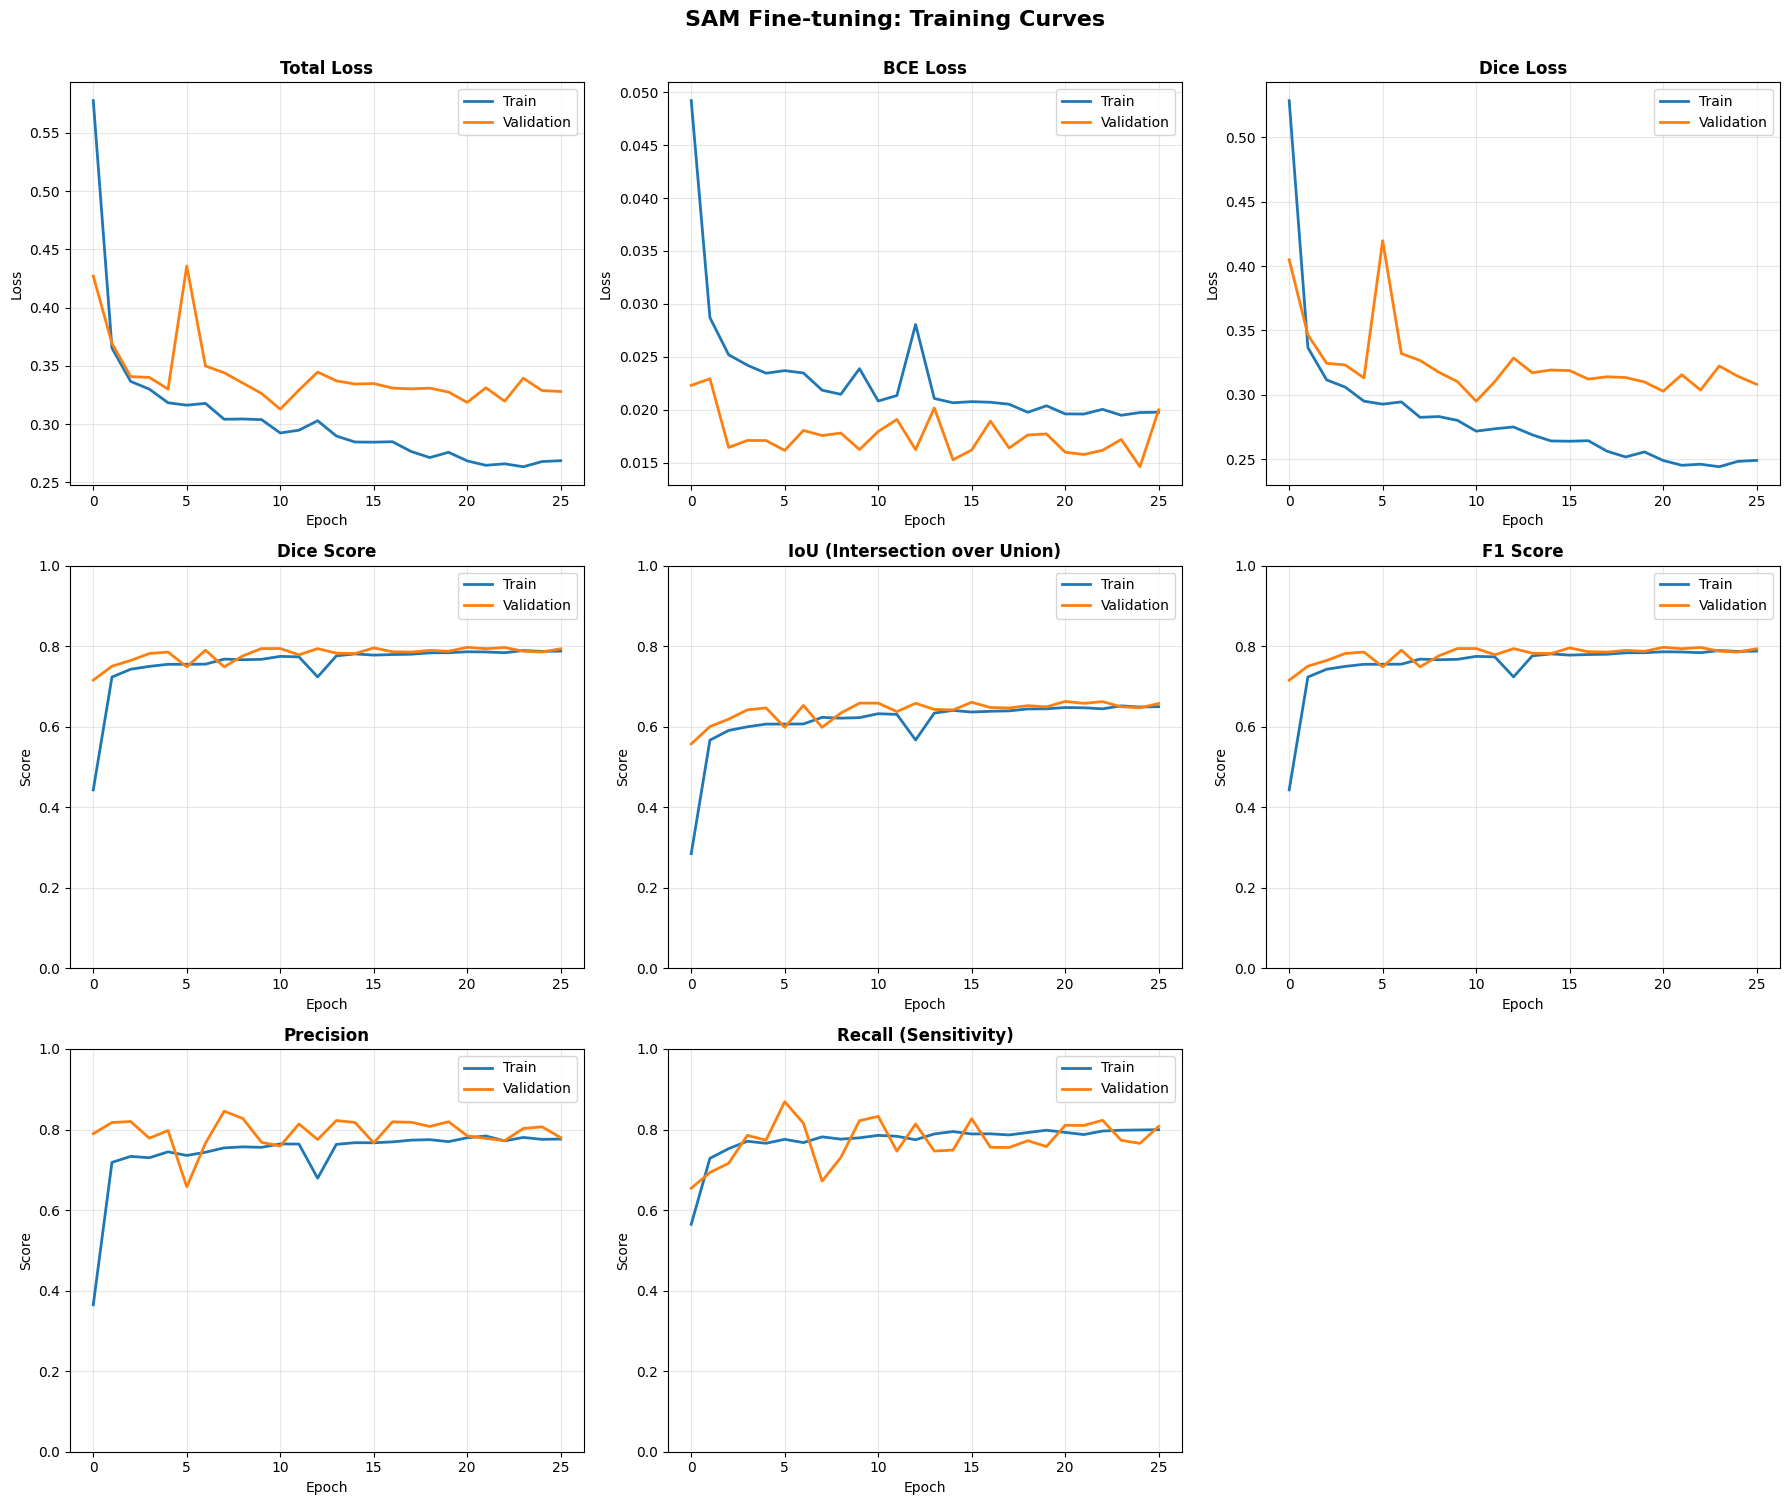

In [ ]:
plot_all_metrics(history)

Loaded best model from epoch 21
Best Validation Dice: 0.7972
Applied LoRA (rank=8) to 12 transformer blocks
Trainable parameters:    4,353,252 (4.63%)
  - LoRA parameters:     294,912
  - Decoder parameters:  4,058,340


Testing: 100%|██████████| 9/9 [00:48<00:00,  5.37s/it]


TILE-LEVEL TEST RESULTS
Loss:          0.2526
  - BCE Loss:  0.0107
  - Dice Loss: 0.2419

Segmentation Metrics:
  Dice:        0.7740
  IoU:         0.6313
  Precision:   0.7467
  Recall:      0.8034
  F1:          0.7740
Visualizing 6 random samples...



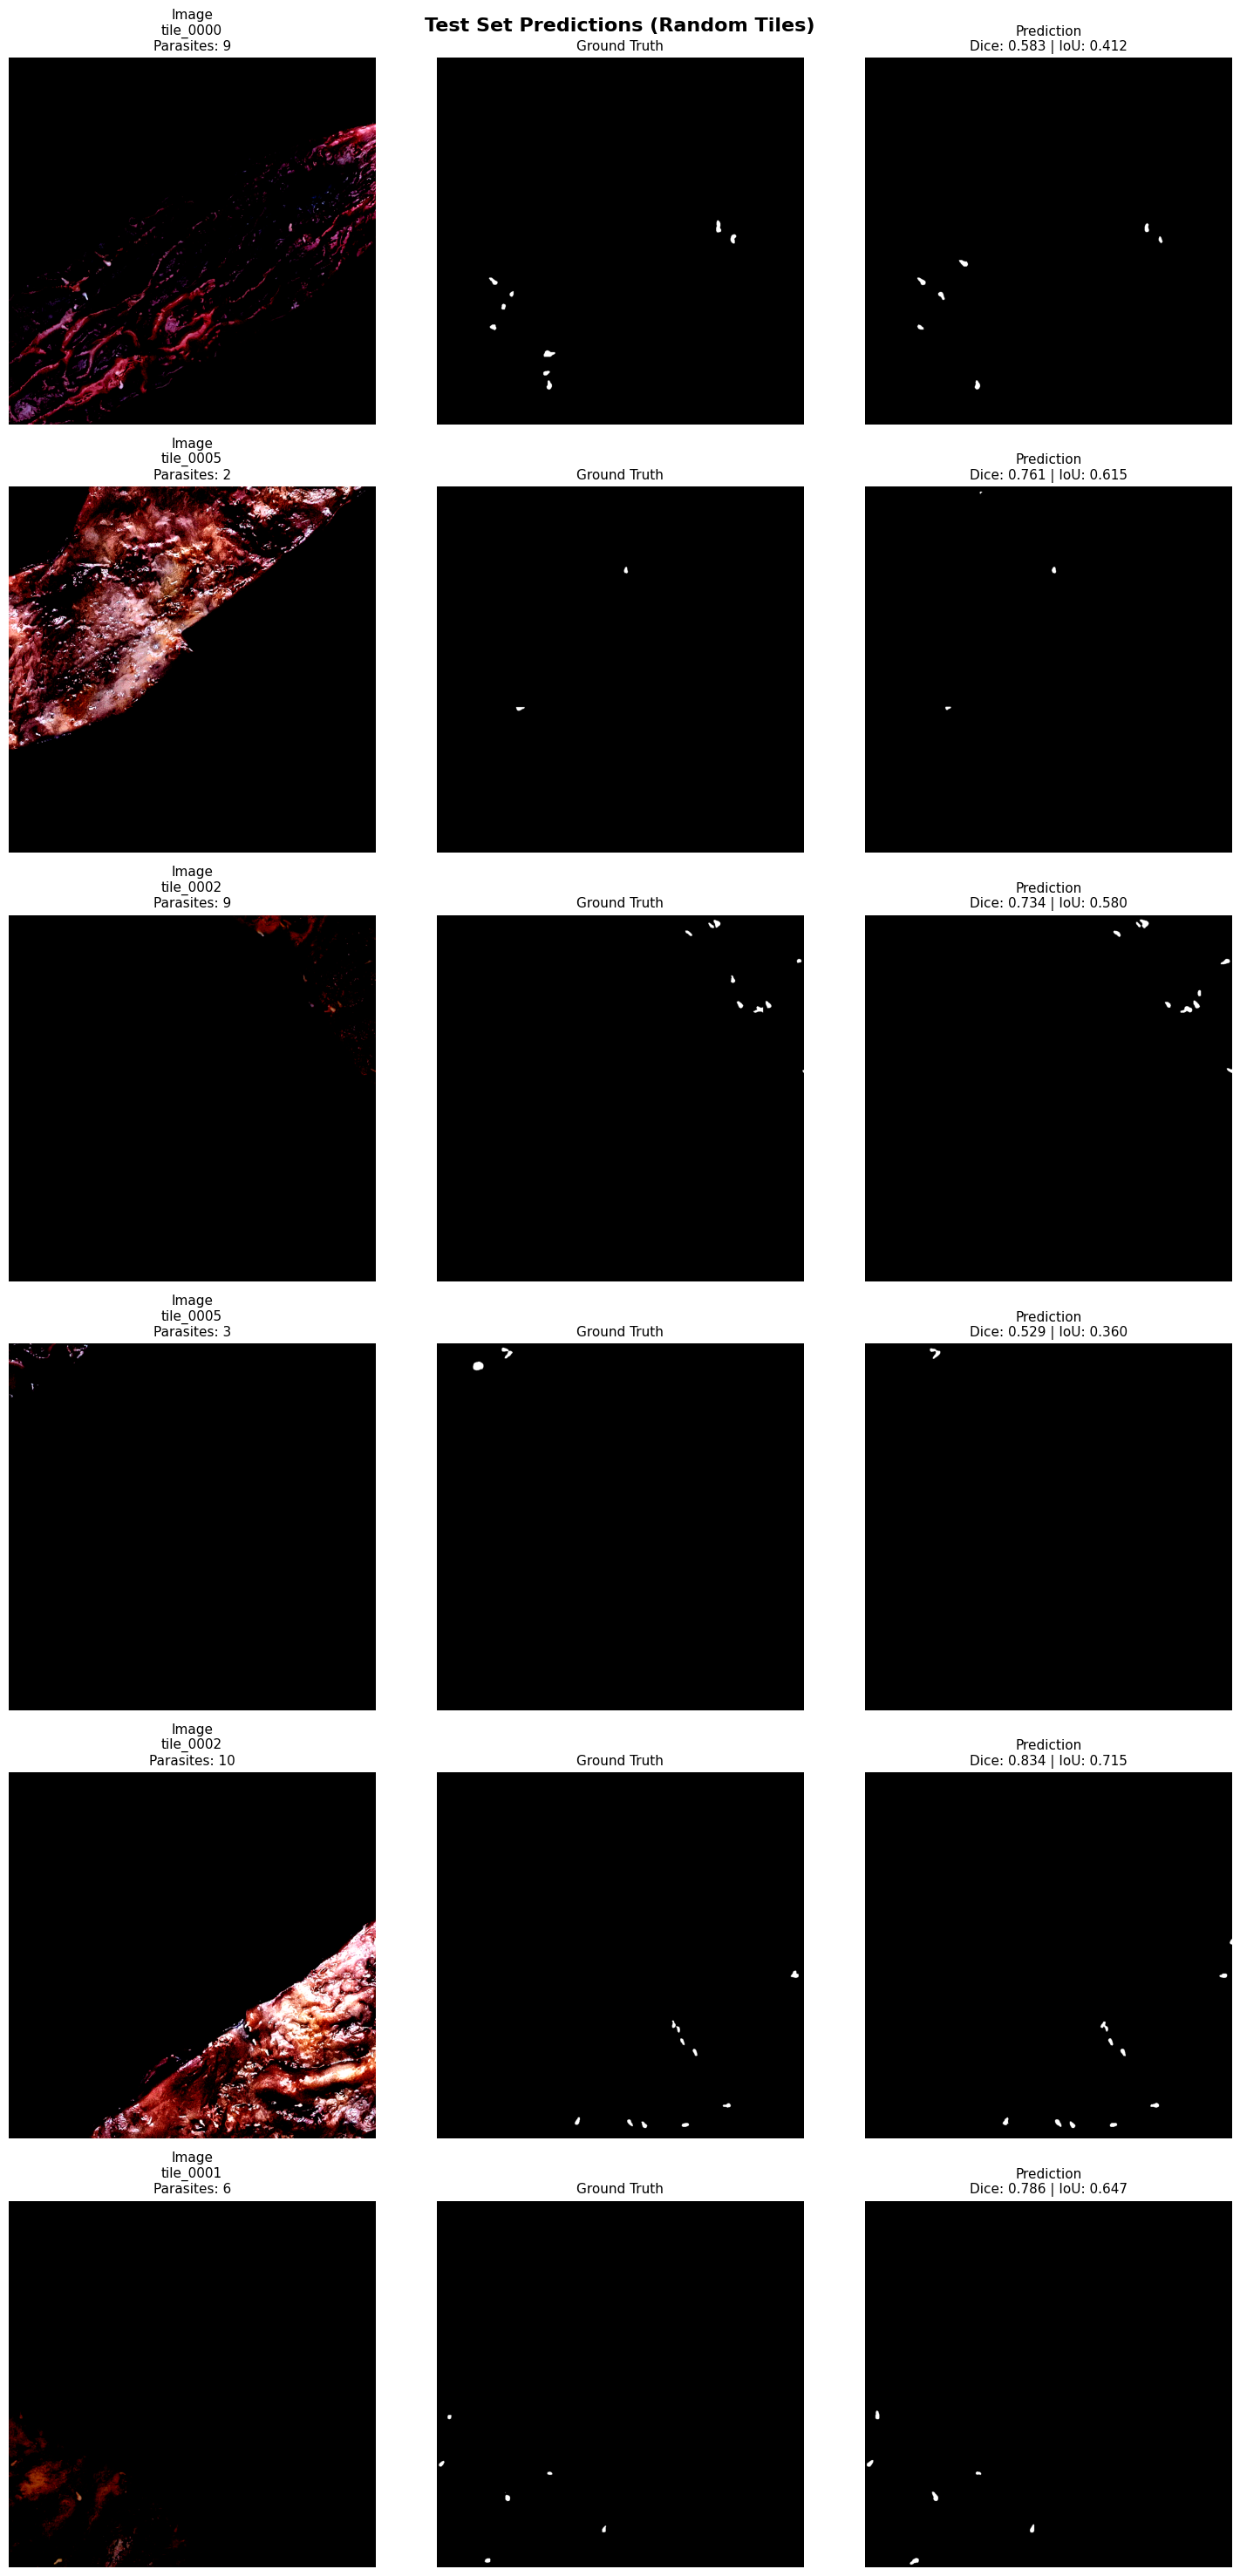

In [ ]:
# Load best checkpoint
best_checkpoint_path = f"{checkpoint_dir}/sam_best.pth"
checkpoint = torch.load(best_checkpoint_path, map_location=device)

print(f"Loaded best model from epoch {checkpoint['epoch']}")
print(f"Best Validation Dice: {checkpoint['best_dice']:.4f}")

sam_model, device = load_sam_model()

# Create fine_tuner with same config as training
eval_fine_tuner = SAMFineTuner_LoRA(
    sam_model=sam_model,
    device=device,
    lora_rank=checkpoint['lora_rank'],
    learning_rate=1e-4,
    bce_weight=checkpoint['bce_weight'],
    dice_weight=checkpoint['dice_weight']
)

# Load the trained weights
eval_fine_tuner.sam.load_state_dict(checkpoint['model_state_dict'])
eval_fine_tuner.sam.eval()

test_results = evaluate_on_test(
    fine_tuner=eval_fine_tuner,
    test_dataset=test_dataset,
    batch_size=4,
    visualize=True,         # Show some example predictions
    num_viz_samples=6       # Number of tiles to visualize
)


FULL IMAGE RECONSTRUCTION WITH VISUALIZATION
Testing on 6 images: ['B2025-00231b', 'B2025-00143b', 'B2025-00206b', 'B2025-00136b', 'B2025-00085.2', 'B2025-00142a']

Processing: B2025-00231b...
  Reconstructing: 4096 x 2805 (~131.5MB, 6 tiles)
  Successfully processed 6/6 tiles
  Dice: 0.7460 | IoU: 0.5949 | Precision: 0.8018 | Recall: 0.6974

Processing: B2025-00143b...
  Reconstructing: 3707 x 3687 (~156.4MB, 7 tiles)
  Successfully processed 7/7 tiles
  Dice: 0.7178 | IoU: 0.5598 | Precision: 0.8317 | Recall: 0.6313

Processing: B2025-00206b...
  Reconstructing: 3660 x 3072 (~128.7MB, 6 tiles)
  Successfully processed 6/6 tiles
  Dice: 0.7715 | IoU: 0.6280 | Precision: 0.8024 | Recall: 0.7430

Processing: B2025-00136b...
  Reconstructing: 4025 x 3433 (~158.1MB, 7 tiles)
  Successfully processed 7/7 tiles
  Dice: 0.7883 | IoU: 0.6506 | Precision: 0.8912 | Recall: 0.7068

Processing: B2025-00085.2...
  Reconstructing: 3207 x 3581 (~131.4MB, 9 tiles)
  Successfully processed 9/9 tiles
 

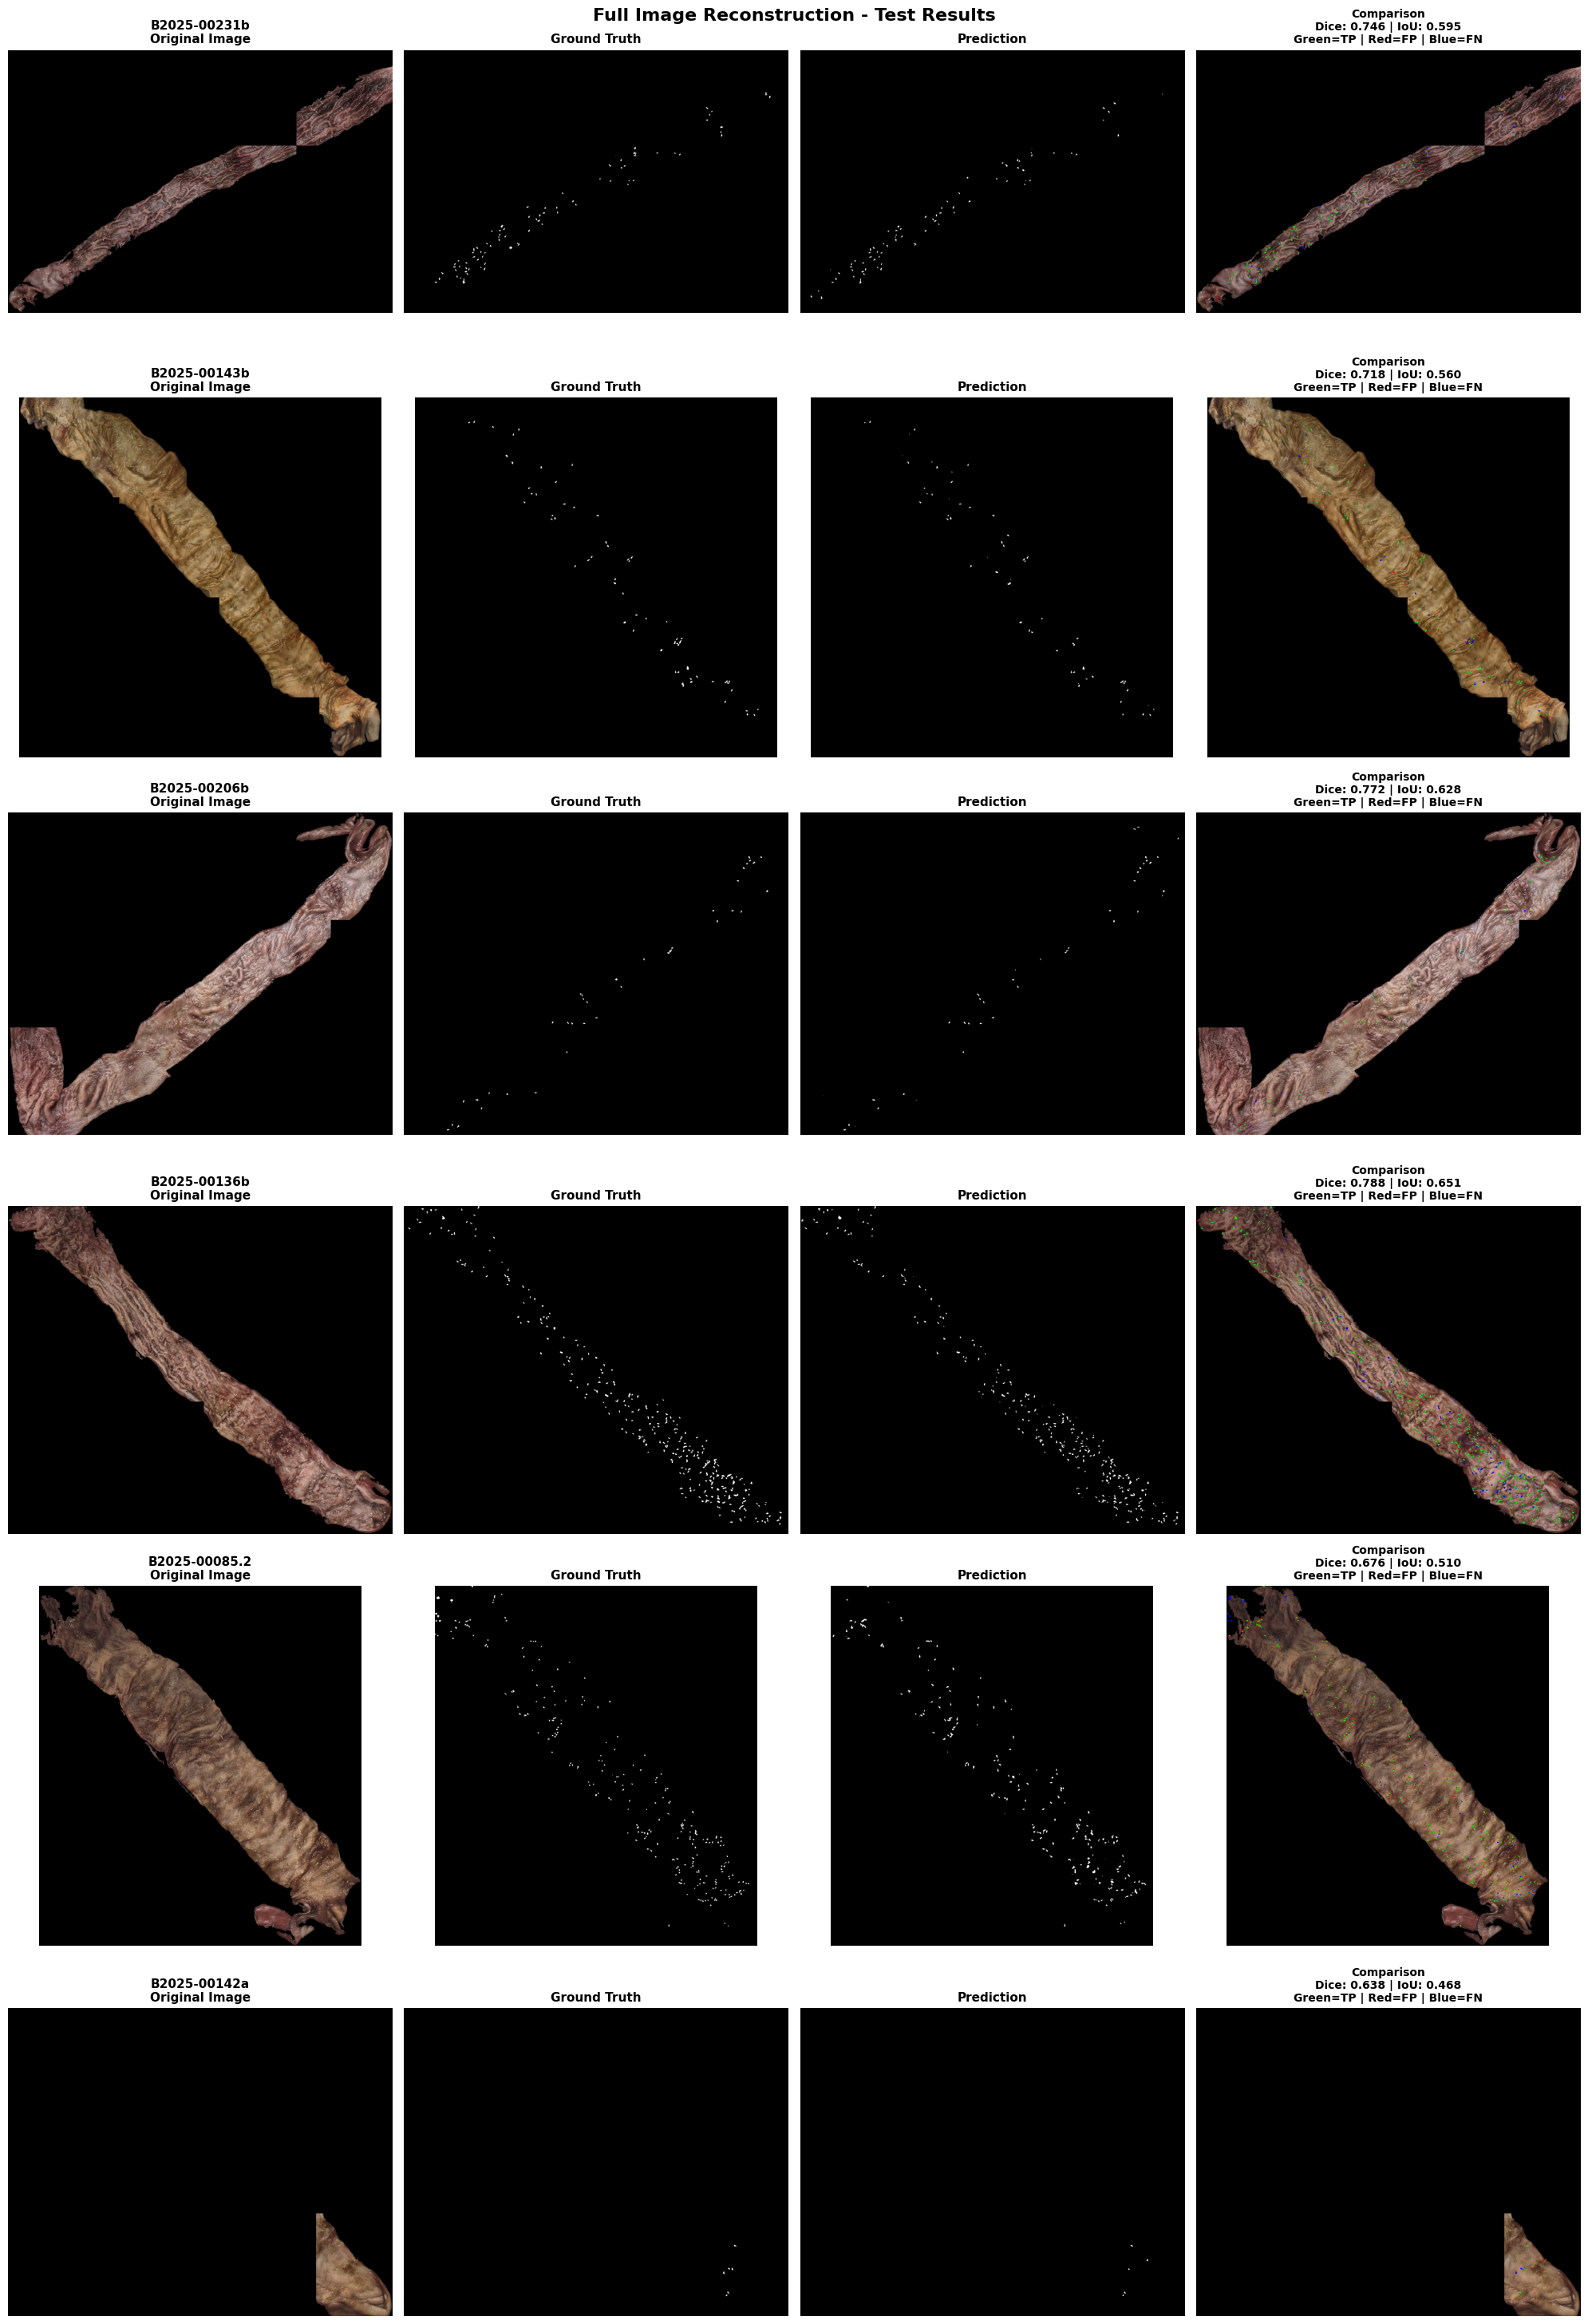

In [ ]:
import pandas as pd
results_df, visualizations = evaluate_full_images(
    fine_tuner=eval_fine_tuner,
    splits=splits,                          # Your train/val/test splits
    test_dataset=test_dataset,
    max_image_size_mb=300,                  # Skip images larger than 300MB
    process_in_chunks=True,                 # Process tiles in chunks
    chunk_size=30,                          # Clear cache every 30 tiles
)